PART A - Data preparation

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
#Loading dataset
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [116]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [117]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [25]:
print("Trading data")
print("Rows: ", trades.shape[0])
print("Columns: ", trades.shape[1])
print("\n")
print("Sentiment Data")
print("Rows: ", sentiment.shape[0])
print("Columns: ", sentiment.shape[1])

Trading data
Rows:  211224
Columns:  16


Sentiment Data
Rows:  2644
Columns:  4


In [26]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [27]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [118]:
#Finding missing values
print("Missing Data")
print("Trading data:")
print(trades.isnull().sum())
print("Sentiment data:")
print(sentiment.isnull().sum())

Missing Data
Trading data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Sentiment data:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [119]:
#Finding duplicate values
print("Duplicate Data")
print("Trading data:")
print(trades.duplicated().sum())
print("Sentiment data:")
print(sentiment.duplicated().sum())

Duplicate Data
Trading data:
0
Sentiment data:
0


In [121]:
trades.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Account,211224,32,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coin,211224,246,HYPE,68005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Execution Price,211224.0,NaN,NaN,NaN,11414.72335,29447.654868,0.000005,4.8547,18.28,101.58,109004.0
Size Tokens,211224.0,NaN,NaN,NaN,4623.364979,104272.88953,0.000001,2.94,32.0,187.9025,15822438.0
Size USD,211224.0,NaN,NaN,NaN,5639.45121,36575.138546,0.0,193.79,597.045,2058.96,3921430.72
Side,211224,2,SELL,108528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp IST,211224,27977,14-02-2025 00:31,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start Position,211224.0,NaN,NaN,NaN,-29946.248839,673807.423736,-14334629.0,-376.231075,84.727932,9337.2775,30509482.0
Direction,211224,12,Open Long,49895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Closed PnL,211224.0,NaN,NaN,NaN,48.749001,919.164828,-117990.1041,0.0,0.0,5.792797,135329.0901


In [122]:
sentiment.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,2644.0,NaN,NaN,NaN,1631898885.022693,65979674.322218,1517463000.0,1574811000.0,1631899800.0,1688988600.0,1746163800.0
value,2644.0,NaN,NaN,NaN,46.981089,21.82768,5.0,28.0,46.0,66.0,95.0
classification,2644,5,Fear,781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,2644,2644,2018-02-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
print("Coins :", trades["Coin"].nunique())
print("Accounts ", trades["Account"].nunique())
print("Sides")
print(trades["Side"].value_counts())
print("Directions")
print(trades["Direction"].value_counts())
print("Sentiment Classes")
print(sentiment["classification"].value_counts())

Coins : 246
Accounts  32
Sides
Side
SELL    108528
BUY     102696
Name: count, dtype: int64
Directions
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64
Sentiment Classes
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [124]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

In [125]:
trades.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [126]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], format="%d-%m-%Y %H:%M")

In [127]:
sentiment['date'] = pd.to_datetime(sentiment['date'], format="%Y-%m-%d")

Q2. Converting timestamp and aligning dataset by date 

In [128]:
trades['trade_date'] = trades['timestamp_ist'].dt.date

In [129]:
sentiment['trade_date']  = sentiment['date'].dt.date

In [130]:
trades[['timestamp_ist', 'trade_date']].head()

,timestamp_ist,trade_date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [131]:
sentiment[['date', 'trade_date']].head()

,date,trade_date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [132]:
#Merging datasets
merged_df = pd.merge(trades, sentiment[['trade_date', 'classification']], on='trade_date', how='left')

In [133]:
merged_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [48]:
merged_df['classification'].value_counts(dropna=False)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

Q3. Key Metrics

In [55]:
daily_pnl = (merged_df.groupby(['trade_date', 'account'], as_index=False)[['closed_pnl']].sum())
daily_pnl.rename(columns = {'closed_pnl': 'Daily_pnl'}, inplace = True)
daily_pnl.head()

,trade_date,account,Daily_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [58]:
avg_trade_size = (merged_df.groupby(['trade_date', 'account'], as_index=False)
    [['size_usd']].mean())
avg_trade_size.rename(columns={'size_usd':'Avg_Trade_Size'}, inplace=True)
avg_trade_size.head()

,trade_date,account,Avg_Trade_Size
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,159.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5556.203333
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,10291.213636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5304.975000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5116.256667


In [59]:
daily_trades = (merged_df.groupby(['trade_date', 'account'], as_index=False).size())
daily_trades.rename(columns={'size':'Trade Per Day'}, inplace=True)
daily_trades.head()

,trade_date,account,Trade Per Day
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3


In [60]:
merged_df['win'] = np.where(merged_df['closed_pnl']>0, 1, 0)

In [62]:
win_rate = (merged_df.groupby(['trade_date', 'account'], as_index=False)[['win']].mean())
win_rate.rename(columns={'win':'win rate'}, inplace=True)
win_rate.head()

,trade_date,account,win rate
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.363636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [64]:
long_short = pd.crosstab(merged_df['trade_date'], merged_df['side'])
long_short.head()

side,BUY,SELL
trade_date,,
2023-05-01,3,0
2023-12-05,7,2
2023-12-14,5,6
2023-12-15,2,0
2023-12-16,3,0


In [65]:
daily_fee = (merged_df.groupby(['trade_date', 'account'], as_index=False)[['fee']].sum())
daily_fee.rename(columns={'fee':'daily_fee'}, inplace=True)
daily_fee.head()

,trade_date,account,daily_fee
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,12.501455
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,28.300831
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.652489
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3.837189


In [68]:
daily_volume = (merged_df.groupby(['trade_date', 'account'], as_index=False)
    [['size_usd']].sum())
daily_volume.rename(columns={'size_usd':'Daily Volume'}, inplace=True)
daily_volume.head()

,trade_date,account,Daily Volume
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,477.00
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,50005.83
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,113203.35
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,10609.95
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,15348.77


In [73]:
features = daily_pnl.merge(win_rate,on=["trade_date","account"])
features = features.merge(avg_trade_size,on=["trade_date","account"])
features = features.merge(daily_trades,on=["trade_date","account"])
features = features.merge(daily_volume,on=["trade_date","account"])
features = features.merge(daily_fee,on=["trade_date","account"])
features = features.merge(sentiment[['trade_date', 'classification']], on=['trade_date'], how='left')
features.head()

,trade_date,account,Daily_pnl,win rate,Avg_Trade_Size,Trade Per Day,Daily Volume,daily_fee,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3,477.00,0.000000,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9,50005.83,12.501455,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,0.363636,10291.213636,11,113203.35,28.300831,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,0.000000,5304.975000,2,10609.95,2.652489,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5116.256667,3,15348.77,3.837189,Greed


In [76]:
features = features.sort_values(by=['account', 'trade_date'])
features['cumulative_pnl'] = features.groupby('account')['Daily_pnl'].cumsum()
features['running_peak'] = features.groupby('account')['cumulative_pnl'].cummax()
features['drawdown'] = features['running_peak'] - features['cumulative_pnl']
features.head()

,trade_date,account,Daily_pnl,win rate,Avg_Trade_Size,Trade Per Day,Daily Volume,daily_fee,classification,cumulative_pnl,running_peak,drawdown
512,2024-11-11,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,0.000000,5089.718249,177,900880.13,167.796055,Extreme Greed,0.0,0.0,0.0
535,2024-11-17,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,0.000000,7976.664412,68,542413.18,67.883615,Extreme Greed,0.0,0.0,0.0
539,2024-11-18,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,0.000000,23734.500000,40,949380.00,94.937983,Extreme Greed,0.0,0.0,0.0
561,2024-11-22,0x083384f897ee0f19899168e3b1bec365f52a9012,-21227.0,0.000000,28186.666667,12,338240.00,33.823995,Extreme Greed,-21227.0,0.0,21227.0
576,2024-11-26,0x083384f897ee0f19899168e3b1bec365f52a9012,1603.1,0.444444,17248.148148,27,465700.00,104.622490,Extreme Greed,-19623.9,0.0,19623.9


PART B - Analysis

Q1. Classification vs Performance

                Average_PnL  Median_PnL       Std_PnL        Max_PnL  \
classification                                                         
Extreme Fear    4619.439053  218.377399  29534.839183  229058.684298   
Extreme Greed   5161.922644  418.319862  27496.863832  449328.107544   
Fear            5328.818161  107.892532  31659.771538  533974.662903   
Greed           3318.100730  158.214922  30599.040173  375620.270243   
Neutral         3438.618818  167.551743  17447.863645  194499.072534   

                      Min_PnL  Observations  
classification                               
Extreme Fear    -77308.420095           160  
Extreme Greed  -132271.000000           526  
Fear           -108604.496278           630  
Greed          -358963.139984           648  
Neutral        -113601.020138           376  


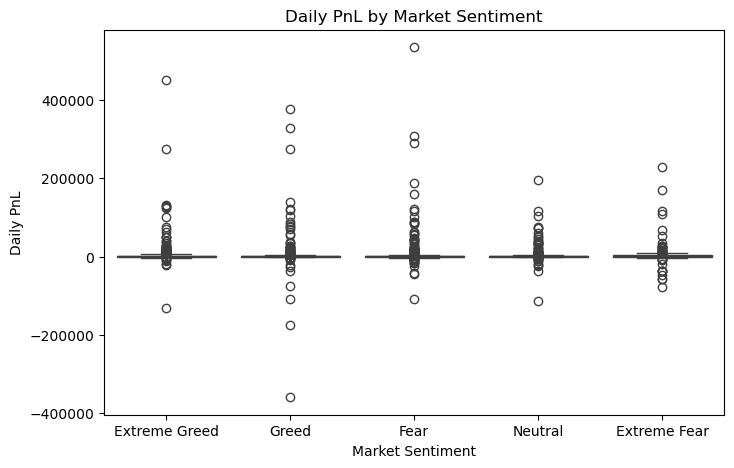

In [80]:
performance_summary = (features.groupby("classification").agg(
        Average_PnL=("Daily_pnl", "mean"),
        Median_PnL=("Daily_pnl", "median"),
        Std_PnL=("Daily_pnl", "std"),
        Max_PnL=("Daily_pnl", "max"),
        Min_PnL=("Daily_pnl", "min"),
        Observations=("Daily_pnl", "count")
    )
)
print(performance_summary)

plt.figure(figsize=(8,5))
sns.boxplot(data=features,x="classification",y="Daily_pnl")
plt.title("Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")
plt.show()

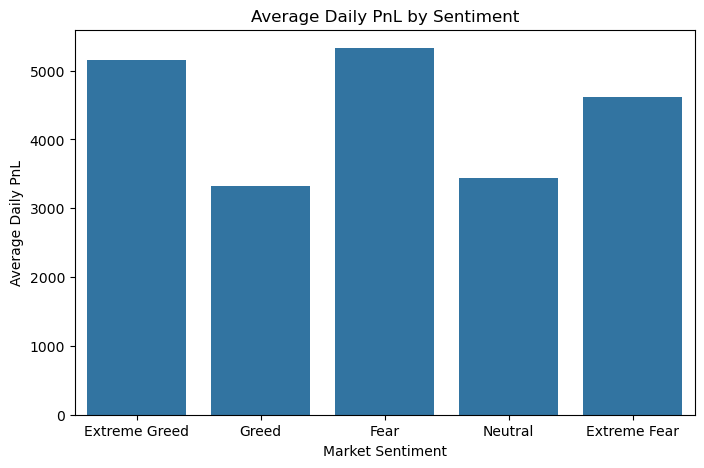

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(data=features,x="classification",y="Daily_pnl",estimator=np.mean,errorbar=None)
plt.title("Average Daily PnL by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.show()

                Average_Win_Rate  Median_Win_Rate  Std_Win_Rate
classification                                                 
Extreme Fear            0.329659         0.307738      0.320043
Extreme Greed           0.386387         0.357143      0.343814
Fear                    0.364033         0.315302      0.353571
Greed                   0.343559         0.289182      0.343731
Neutral                 0.355414         0.321091      0.333569


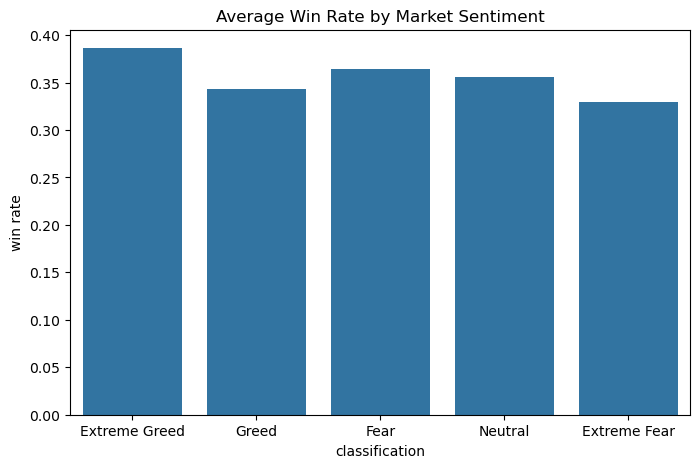

In [87]:
winrate_summary = (features.groupby("classification").agg(
        Average_Win_Rate=("win rate", "mean"),
        Median_Win_Rate=("win rate", "median"),
        Std_Win_Rate=("win rate", "std")
    )
)
print(winrate_summary)

plt.figure(figsize=(8,5))
sns.barplot(data=features,x="classification",y="win rate",estimator=np.mean,errorbar=None)
plt.title("Average Win Rate by Market Sentiment")
plt.show()

                Average_Drawdown  Median_Drawdown  Maximum_Drawdown
classification                                                     
Extreme Fear         9240.531028              0.0      96624.119183
Extreme Greed        5504.652345              0.0     256111.935958
Fear                 8767.361384              0.0     113383.715290
Greed               11642.727362              0.0     369393.229261
Neutral              9431.377301              0.0     116594.595363


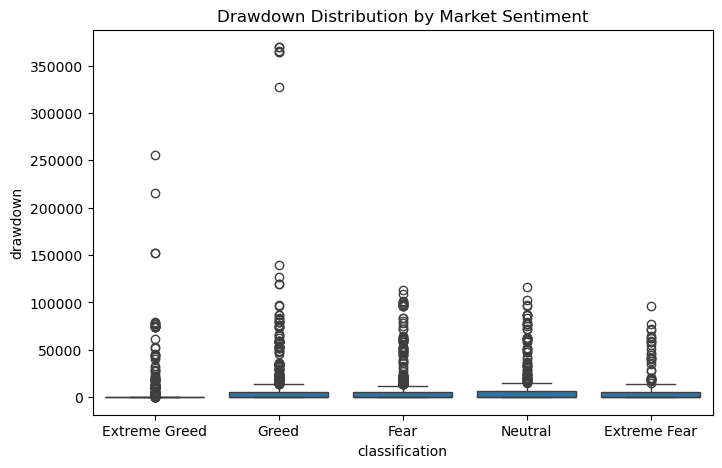

In [89]:
drawdown_summary = (features.groupby("classification").agg(
        Average_Drawdown=("drawdown", "mean"),
        Median_Drawdown=("drawdown", "median"),
        Maximum_Drawdown=("drawdown", "max")
    )
)
print(drawdown_summary)

plt.figure(figsize=(8,5))
sns.boxplot(data=features,x="classification",y="drawdown")
plt.title("Drawdown Distribution by Market Sentiment")
plt.show()

In [91]:
performance_table = (features.groupby("classification").agg(
        Avg_PnL=("Daily_pnl","mean"),
        Avg_Win_Rate=("win rate","mean"),
        Avg_Drawdown=("drawdown","mean"),
        Avg_Trades=("Trade Per Day","mean")
    )
)
performance_table

,Avg_PnL,Avg_Win_Rate,Avg_Drawdown,Avg_Trades
classification,,,,
Extreme Fear,4619.439053,0.329659,9240.531028,133.750000
Extreme Greed,5161.922644,0.386387,5504.652345,76.030418
Fear,5328.818161,0.364033,8767.361384,98.153968
Greed,3318.100730,0.343559,11642.727362,77.628086
Neutral,3438.618818,0.355414,9431.377301,100.228723


Q2. Classification vs Behavior

In [98]:
trade_frequency = (
features.groupby("classification").agg(
        Avg_Trades=("Trade Per Day","mean"),
        Median_Trades=("Trade Per Day","median"),
        Max_Trades=("Trade Per Day","max")
    )
)
print(trade_frequency)

                Avg_Trades  Median_Trades  Max_Trades
classification                                       
Extreme Fear    133.750000           50.5        1651
Extreme Greed    76.030418           31.5        2076
Fear             98.153968           26.0        3292
Greed            77.628086           25.0        1950
Neutral         100.228723           29.5        4083


In [99]:
trade_size = (features.groupby("classification").agg(
        Avg_Trade_Size=("Avg_Trade_Size","mean"),
        Median_Trade_Size=("Avg_Trade_Size","median")
    )
)
trade_size

,Avg_Trade_Size,Median_Trade_Size
classification,,
Extreme Fear,6773.464125,2315.629870
Extreme Greed,5371.637182,2003.480176
Fear,8975.928546,1752.677497
Greed,6427.866594,2052.534828
Neutral,6963.694861,1704.405417


In [100]:
volume_summary = (features.groupby("classification").agg(
        Avg_Daily_Volume=("Daily Volume","mean"),
        Median_Daily_Volume=("Daily Volume","median")
    )
)
volume_summary

,Avg_Daily_Volume,Median_Daily_Volume
classification,,
Extreme Fear,715526.634000,128229.925
Extreme Greed,236625.788156,61028.670
Fear,767182.206016,69699.270
Greed,445343.356049,61186.925
Neutral,479367.189043,75725.155


In [102]:
long_short = (merged_df.groupby(["classification","side"]).size().reset_index(name="Count"))
long_short

,classification,side,Count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


Q3. Segment Analysis

In [107]:
q1 = features["Trade Per Day"].quantile(0.25)
q3 = features["Trade Per Day"].quantile(0.75)
def trade_segment(x):
    if x <= q1:
        return "Low Frequency"
    elif x >= q3:
        return "High Frequency"
    else:
        return "Medium Frequency"
features["Trade Segment"] = (features["Trade Per Day"].apply(trade_segment))

features.groupby("Trade Segment").agg(
    Avg_PnL=("Daily_pnl","mean"),
    Avg_WinRate=("win rate","mean"),
    Avg_Drawdown=("drawdown","mean")
)

,Avg_PnL,Avg_WinRate,Avg_Drawdown
Trade Segment,,,
High Frequency,11210.677074,0.420142,8944.993073
Low Frequency,879.026254,0.278387,8977.201129
Medium Frequency,2767.367743,0.371572,8969.682584


In [138]:
q1 = features["win rate"].quantile(0.25)
q3 = features["win rate"].quantile(0.75)
def winner_segment(x):
    if x >= q3:
        return "Consistent Trader"
    elif x <= q1:
        return "Inconsistent Trader"
    else:
        return "Average Trader"
        
features["Winner Segment"] = (features["win rate"].apply(winner_segment))
features.groupby("Winner Segment").agg(
    Avg_PnL=("Daily_pnl","mean"),
    Avg_Drawdown=("drawdown","mean")
)

,Avg_PnL,Avg_Drawdown
Winner Segment,,
Average Trader,3506.823491,9329.311595
Consistent Trader,12985.273556,7360.043123
Inconsistent Trader,-1128.051625,9733.225827


In [113]:
q1 = features["Daily Volume"].quantile(0.25)
q3 = features["Daily Volume"].quantile(0.75)

def volume_segment(x):
    if x <= q1:
        return "Low Volume"
    elif x >= q3:
        return "High Volume"
    else:
        return "Medium Volume"
features["Volume Segment"] = (features["Daily Volume"].apply(volume_segment))

features.groupby("Volume Segment").agg(
    Avg_PnL=("Daily_pnl","mean"),
    Avg_Drawdown=("drawdown","mean")
)

,Avg_PnL,Avg_Drawdown
Volume Segment,,
High Volume,12817.708393,12499.175627
Low Volume,249.942481,5428.168215
Medium Volume,2257.754945,8967.178335


Q4. Insights

Insight 1 - Fear periods were associated with stronger trading performance than Greed periods. Traders achieved a higher average daily PnL (5,328 vs 3,318) while also experiencing a lower average drawdown (8,767 vs 11,643). This indicates that traders were able to generate better returns with comparatively lower downside risk during Fear periods. Evidence:

In [134]:
performance_table

,Avg_PnL,Avg_Win_Rate,Avg_Drawdown,Avg_Trades
classification,,,,
Extreme Fear,4619.439053,0.329659,9240.531028,133.750000
Extreme Greed,5161.922644,0.386387,5504.652345,76.030418
Fear,5328.818161,0.364033,8767.361384,98.153968
Greed,3318.100730,0.343559,11642.727362,77.628086
Neutral,3438.618818,0.355414,9431.377301,100.228723


Insight 2 - Traders behavior changed noticeably during different market sentiments. Average trade was highest during Extreme Fear and lowest during Extreme greed. This says that traders have to adjust their positions on base on market sentiments. Evidence:

In [135]:
trade_frequency

,Avg_Trades,Median_Trades,Max_Trades
classification,,,
Extreme Fear,133.750000,50.5,1651
Extreme Greed,76.030418,31.5,2076
Fear,98.153968,26.0,3292
Greed,77.628086,25.0,1950
Neutral,100.228723,29.5,4083


Insight 3 - Higher or lower trading frequency alone does not guarantee better performance. Consistent Traders achieved substantially higher profitability while executing fewer trades than Average Traders, suggesting that trade quality and disciplined execution are more important than trading quantity. Evidence:

In [141]:
winner_summary = (features.groupby("Winner Segment").agg(
        Avg_Daily_PnL=("Daily_pnl", "mean"),
        Avg_Drawdown=("drawdown", "mean"),
        Avg_Win_Rate=("win rate", "mean"),
        Avg_Trades=("Trade Per Day", "mean")
    )
)
winner_summary

,Avg_Daily_PnL,Avg_Drawdown,Avg_Win_Rate,Avg_Trades
Winner Segment,,,,
Average Trader,3506.823491,9329.311595,0.338500,143.101291
Consistent Trader,12985.273556,7360.043123,0.856175,79.592150
Inconsistent Trader,-1128.051625,9733.225827,0.000000,27.379679


**PART C - ACTIONABLE OUTPUT**

STRATEGY 1 - Sentiment Adaptive Risk Management

**Evidence:**  
Greed has lowest average daily pnl = 3,318  
Greed had highest average drawdown = 11,642  
  
**Recommendation:**  
During Greed periods, reduce position size and tighten risk controls because these periods were associated with the highest downside risk and the lowest average profitability. Conversely, during Fear periods, traders may cautiously increase exposure while maintaining disciplined risk management, as Fear periods showed higher average profitability with comparatively lower drawdown. 
  
**Source:**  
performance_table(table)

STRATEGY 2 - Quality Over Quantity

**Evidence:**  
In terms of average daily pnl, drawdown, average win rate, and average trades:  
Consistent Trader is better than Average and Inconsistent Trader.

**Recommendation**  
Encourage selective trade execution rather than maximizing trade frequency. The analysis shows that Consistent Traders achieved substantially higher profitability while executing fewer trades than Average Traders. This indicates that disciplined trade selection and execution quality are more effective than simply increasing the number of trades.  

**Source:**  
winner_summary(table)